<a href="https://colab.research.google.com/github/Biacrispim/introducao-a-Ciencia-de-Dados/blob/main/Analise_do_banco_da_Netflix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#INTRODUÇÃO

# Projeto Final - Introdução à Ciência de Dados

# Aluna: Julia Beatriz, Vinicius Costa
# Professor: Alexandre Roriz
# Disciplina: Introdução à Ciência de Dados


#Descrição do Dataset

#O conjunto de dados utilizado contém informações sobre filmes e séries
#disponíveis na Netflix, incluindo:

#- Tipo de conteúdo
#- Diretor
#- País
#- Ano de lançamento
#- Classificação indicativa
#- Categorias

#O objetivo é identificar padrões e características presentes no catálogo.


In [ ]:
import pandas as pd

nt = pd.read_csv('https://raw.githubusercontent.com/adamerose/datasets/master/netflix_titles.csv')

# Traduzir as colunas
nt = nt.rename(columns={
    "show_id": "id",
    "type": "tipo",
    "title": "titulo",
    "director": "diretor",
    "cast": "elenco",
    "country": "pais",
    "date_added": "data_adicionada",
    "release_year": "ano_lancamento",
    "rating": "classificacao",
    "duration": "duracao",
    "listed_in": "categoria",
    "description": "descricao"
})


# Arrumar as datas
nt["data_adicionada"] = pd.to_datetime(
    nt["data_adicionada"],
    errors="coerce"
).dt.strftime("%d/%m/%Y")

nt.head(10)



# Inicialmente, foi realizada a importação das bibliotecas necessárias para a análise dos dados.
# Em seguida, o conjunto de dados da Netflix foi carregado e suas colunas foram traduzidas para o português,
# facilitando a compreensão das informações. Também foram realizados tratamentos básicos,
# como a conversão de datas e a organização dos dados para as etapas seguintes da análise exploratória.


,id,tipo,titulo,diretor,elenco,pais,data_adicionada,ano_lancamento,classificacao,duracao,categoria,descricao
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14/08/2020,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,23/12/2016,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,20/12/2018,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,16/11/2017,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,01/01/2020,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...
5,s6,TV Show,46,Serdar Akar,"Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan...",Turkey,01/07/2017,2016,TV-MA,1 Season,"International TV Shows, TV Dramas, TV Mysteries",A genetics professor experiments with a treatm...
6,s7,Movie,122,Yasir Al Yasiri,"Amina Khalil, Ahmed Dawood, Tarek Lotfy, Ahmed...",Egypt,01/06/2020,2019,TV-MA,95 min,"Horror Movies, International Movies","After an awful accident, a couple admitted to ..."
7,s8,Movie,187,Kevin Reynolds,"Samuel L. Jackson, John Heard, Kelly Rowan, Cl...",United States,01/11/2019,1997,R,119 min,Dramas,After one of his high school students attacks ...
8,s9,Movie,706,Shravan Kumar,"Divya Dutta, Atul Kulkarni, Mohan Agashe, Anup...",India,01/04/2019,2019,TV-14,118 min,"Horror Movies, International Movies","When a doctor goes missing, his psychiatrist w..."
9,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15/12/2017,2008,TV-MA,143 min,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...


<Axes: title={'center': 'Gênero de filme mais assistido na plataforma Netflix'}, ylabel='categoria'>

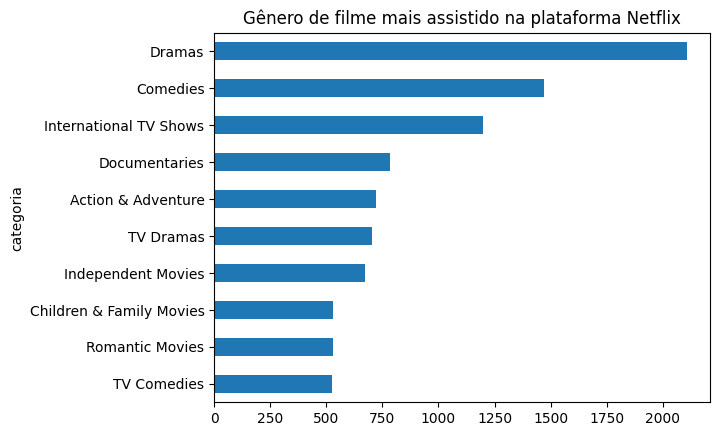

In [ ]:
#1- Qual genero de filme mais assistido na plataforma Netflix?

df_tratamento = nt['categoria']
df_tratamento = df_tratamento.dropna()
df_tratamento = df_tratamento.str.split(', ')
df_tratamento = df_tratamento.explode()
df_tratamento = df_tratamento[df_tratamento != 'International Movies']

genero_mais_assistido = df_tratamento.value_counts()

genero_mais_assistido.head(10).sort_values(ascending=True).plot.barh(title='Gênero de filme mais assistido na plataforma Netflix')




# Aqui foi realizada a separação dos gêneros presentes em cada título e a contagem
# da frequência de ocorrência de cada um deles. O resultado permite identificar quais gêneros
# são mais populares dentro do catálogo da Netflix e compreender melhor o perfil dos conteúdos oferecidos pela plataforma.


<Axes: title={'center': 'País com mais produções na plataforma Netflix'}, ylabel='count'>

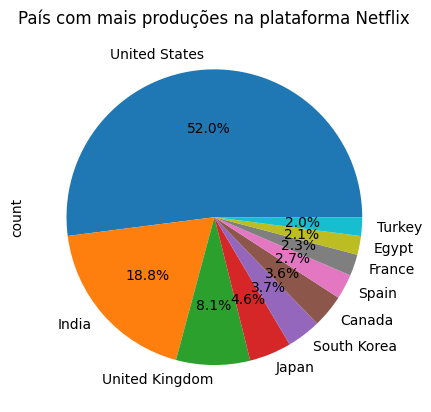

In [ ]:
#2-Qual país possui mais produções?

pais_mais_producoes = nt['pais'].value_counts()

pais_mais_producoes.head(10).plot.pie(title='País com mais produções na plataforma Netflix',autopct='%1.1f%%')




# Nesta Célula foi realizada a contagem da quantidade de títulos produzidos por cada país presente no dataset.
# O gráfico permite visualizar quais países possuem maior representatividade no catálogo da Netflix,
# destacando os principais produtores de conteúdo da plataforma.


<Axes: title={'center': 'Ano com mais lançamento na plataforma Netflix'}, xlabel='ano_lancamento'>

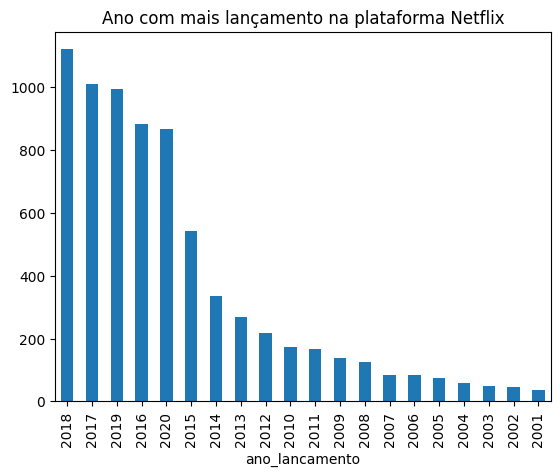

In [ ]:
#3-Qual ano teve mais lançamento?

ano_mais_lancamento = nt['ano_lancamento'].value_counts()

ano_mais_lancamento.head(20).plot.bar(title='Ano com mais lançamento na plataforma Netflix')



# Na análise acima foi contabilizada a quantidade de títulos lançados em cada ano.
# O objetivo é identificar períodos de crescimento da plataforma e observar tendências
# relacionadas à produção e disponibilização de conteúdos ao longo do tempo.


<Axes: title={'center': 'Classificação indicativa'}, ylabel='classificacao'>

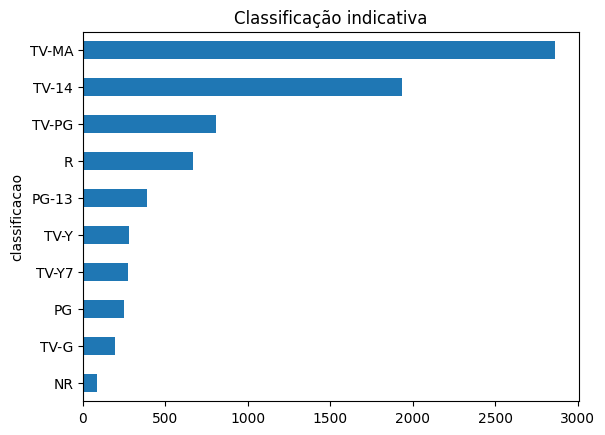

In [ ]:
#4-Qual classificação indicativa aparece mais?

classificacao_mais_assistido = nt['classificacao'].value_counts()

classificacao_mais_assistido.head(10).sort_values(ascending=True).plot.barh(title='Classificação indicativa')



# Foi realizada uma análise das classificações indicativas presentes no catálogo.
# Essa informação permite compreender para qual faixa etária a maior parte dos conteúdos
# da Netflix é direcionada.


<Axes: title={'center': 'Diretor com maior numero de titulos na plataforma '}, ylabel='count'>

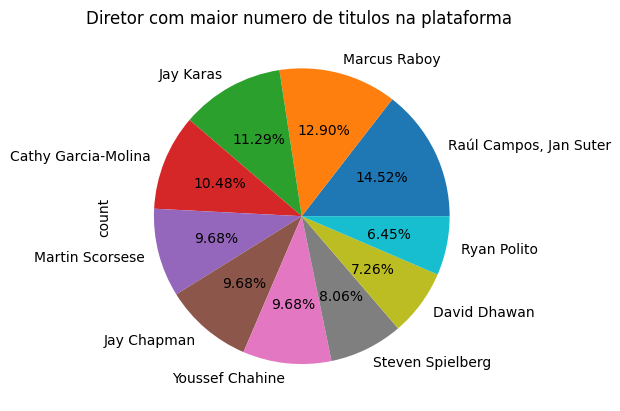

In [ ]:
#5- Qual diretor possui mais títulos na plataforma?

diretor = nt['diretor'].value_counts()

diretor.head(10).plot.pie(title='Diretor com maior numero de titulos na plataforma ',autopct='%1.2f%%')




# Na análise acima foi feita a contagem do número de títulos associados a cada diretor.
# O resultado permite identificar quais profissionais possuem maior participação
# no catálogo da Netflix e contribuíram com mais produções disponíveis na plataforma.


<Axes: title={'center': 'Países com maior diversidade de gêneros'}, xlabel='pais'>

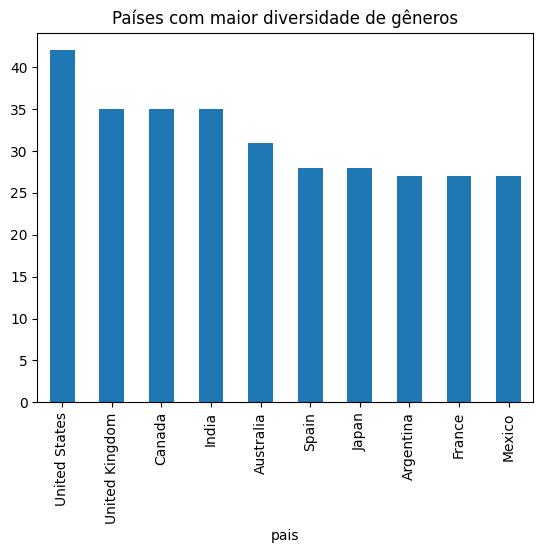

In [ ]:
#6-Quais países têm mais diversidade de gêneros nos catálogos?

tratamento = nt[['pais', 'categoria']].copy()
tratamento = tratamento.dropna(subset=['categoria'])
tratamento['categoria'] = tratamento['categoria'].str.split(', ')
tratamento = tratamento.explode('categoria')


pais_mais_diversidade = tratamento.groupby('pais')['categoria'].nunique().sort_values(ascending=False)

pais_mais_diversidade.head(10).plot.bar(title='Países com maior diversidade de gêneros')




# Para responder essa questão, os gêneros foram separados individualmente e agrupados por país.
# Em seguida, foi calculada a quantidade de gêneros distintos produzidos por cada país.
# Essa análise permite avaliar a diversidade temática das produções de diferentes regiões.


<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_954/1385730112.py:4: SyntaxWarning: invalid escape sequence '\s'
  tratamento['duracao_minutos'] = tratamento['duracao'].str.extract('(\\d+)\smin').astype(float)


<Axes: title={'center': 'Gênero com Filmes Mais Longos (Duração Média em Minutos)'}, ylabel='categoria'>

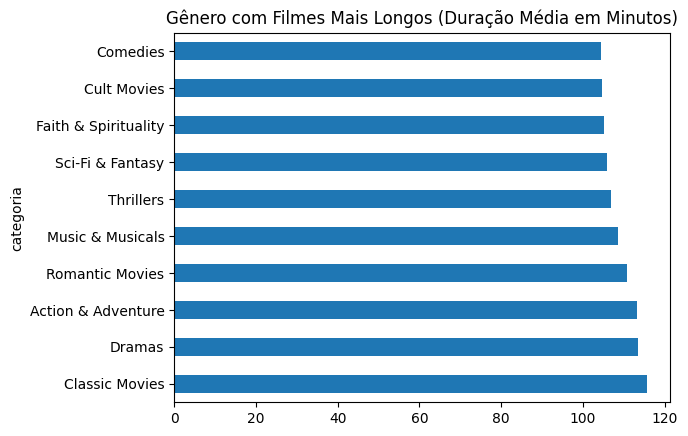

In [ ]:
#7-Qual gênero possui os filmes mais longos da plataforma?

tratamento = nt[nt['tipo'] == 'Movie'].copy()
tratamento['duracao_minutos'] = tratamento['duracao'].str.extract('(\\d+)\smin').astype(float)
tratamento.dropna(subset=['duracao_minutos'], inplace=True)

tratamento_categorias_duracao = tratamento[['categoria', 'duracao_minutos']].copy()
tratamento_categorias_duracao.dropna(subset=['categoria'], inplace=True)
tratamento_categorias_duracao['categoria'] = tratamento_categorias_duracao['categoria'].str.split(', ')
tratamento_categorias_duracao = tratamento_categorias_duracao.explode('categoria')
tratamento_categorias_duracao = tratamento_categorias_duracao[tratamento_categorias_duracao['categoria'] != 'International Movies']

genero_mais_longos = tratamento_categorias_duracao.groupby('categoria')['duracao_minutos'].mean().sort_values(ascending=False)

genero_mais_longos.head(10).plot.barh(title='Gênero com Filmes Mais Longos (Duração Média em Minutos)')




# Foram considerados apenas os registros classificados como filmes.
# A duração foi convertida para valores numéricos e utilizada para calcular a média de duração
# de cada gênero. O resultado permite identificar quais categorias costumam apresentar filmes mais extensos.


<Axes: title={'center': 'Relação entre duração dos filmes e a classificação indicativa'}, ylabel='classificacao'>

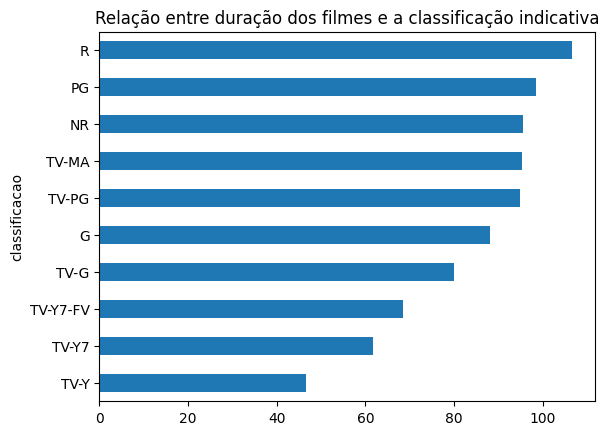

In [ ]:
#8-Existe relação entre duração dos filmes e a classificação indicativa?

tratamento_classificacao_duracao = tratamento[['classificacao', 'duracao_minutos']].copy()

relacao = tratamento_classificacao_duracao.groupby('classificacao')['duracao_minutos'].mean().sort_values()

relacao.head(10).plot.barh(title='Relação entre duração dos filmes e a classificação indicativa')



# Nesta análise foi calculada a duração média dos filmes para cada classificação indicativa.
# O objetivo é verificar se existe alguma tendência entre a faixa etária recomendada e o tempo de duração dos conteúdos.


In [ ]:
# CONCLUSÃO


# A presente análise exploratória permitiu uma compreensão mais aprofundada do conjunto de dados
# referente ao catálogo da Netflix, possibilitando a identificação de padrões, tendências e
# características relevantes presentes na plataforma. Por meio das perguntas elaboradas e das
# visualizações gráficas desenvolvidas, foi possível investigar aspectos como a distribuição dos
# gêneros, a participação dos países na produção de conteúdos, os períodos com maior volume de
# lançamentos, as classificações indicativas predominantes e a atuação dos diretores com maior
# número de títulos disponíveis.

# Além disso, a análise evidenciou a diversidade de conteúdos oferecidos pela Netflix e permitiu
# observar relações entre variáveis importantes, como duração dos filmes, gêneros e público-alvo.
# Os gráficos contribuíram para uma interpretação mais clara dos resultados, tornando a análise
# mais objetiva e intuitiva.

# Dessa forma, o trabalho demonstrou a importância da Análise Exploratória de Dados (AED) como
# etapa fundamental no processo de Ciência de Dados, uma vez que permite conhecer melhor os dados,
# identificar comportamentos relevantes, detectar padrões e gerar insights que podem servir de
# base para estudos mais avançados e para a tomada de decisões orientadas por dados.